## 1. Imports & Setup

In [12]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from groq import Groq
from dotenv import load_dotenv

# add src/ to path so we can import model and dataset
sys.path.insert(0, os.path.join('..', 'src'))
from model import ChestXrayModel
from dataset import LABELS, get_transforms

load_dotenv(os.path.join('..', '.env'))
print('Imports OK')

Imports OK


## 2. Config

In [ ]:
CHECKPOINT  = os.path.join('..', 'outputs', 'checkpoints', 'model_best.pth')
DATA_ENTRY  = r'E:\archive\Data_Entry_2017.csv'   
TEST_LIST   = r'E:\archive\test_list.txt'         
IMAGE_ROOT  = r'E:\archive'                       
GROQ_KEY    = os.getenv('GROQ_API_KEY', '')
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MAX_SAMPLES = 500

print(f'Device: {DEVICE}')
print(f'Checkpoint: {CHECKPOINT}')

Device: cuda
Checkpoint: ..\outputs\checkpoints\model_best.pth


## 3. Load Model from Checkpoint

In [14]:
ckpt  = torch.load(CHECKPOINT, map_location=DEVICE)

print(ckpt.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'scaler_state_dict', 'val_loss', 'val_auc', 'history'])


In [ ]:
ckpt  = torch.load(CHECKPOINT, map_location=DEVICE)
model = ChestXrayModel(num_classes=15, pretrained=False)
model.load_state_dict(ckpt['model_state_dict'])
model.to(DEVICE).eval()

print(f"Loaded checkpoint epoch: {ckpt['epoch']}, "
      f"val_loss: {ckpt['val_loss']:.4f}, val_AUC: {ckpt['val_auc']:.4f}")

c:\Users\deadx\anaconda3\envs\chestxray\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
c:\Users\deadx\anaconda3\envs\chestxray\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded checkpoint ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â epoch: 5, val_loss: 0.9365, val_AUC: 0.8010


## 4. Evaluate on Test Set (requires dataset)

Runs inference on the test CSV and computes per-class AUC-ROC.  
Skips gracefully if the dataset is not present.

In [16]:
transform    = get_transforms(train=False)
image_dirs   = [f'images_{str(i).zfill(3)}/images' for i in range(1, 13)]
all_probs    = None
all_targets  = None

def find_image(filename):
    for folder in image_dirs:
        path = os.path.join(IMAGE_ROOT, folder, filename)
        if os.path.exists(path):
            return path
    return None

try:
    # build test DataFrame from the official test_list.txt split
    test_files = set(open(TEST_LIST).read().splitlines())
    df_full    = pd.read_csv(DATA_ENTRY)
    test_df    = df_full[df_full['Image Index'].isin(test_files)].reset_index(drop=True)

    if MAX_SAMPLES:
        test_df = test_df.sample(MAX_SAMPLES, random_state=42)
    print(f'Evaluating on {len(test_df)} samples...')

    probs_list, targets_list = [], []

    for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
        img_path = find_image(row['Image Index'])
        if img_path is None:
            continue

        img_t    = transform(Image.open(img_path).convert('RGB'))
        # match training preprocessing: age/100, gender M=0 / F=1
        age_t    = torch.tensor([row['Patient Age'] / 100.0], dtype=torch.float32)
        gender_t = torch.tensor([0.0 if row['Patient Gender'] == 'M' else 1.0], dtype=torch.float32)

        with torch.no_grad():
            logits = model(
                img_t.unsqueeze(0).to(DEVICE),
                age_t.unsqueeze(0).to(DEVICE),
                gender_t.unsqueeze(0).to(DEVICE)
            )
            p = torch.sigmoid(logits).squeeze().cpu().numpy()

        target = np.array([1.0 if lbl in row['Finding Labels'] else 0.0 for lbl in LABELS])
        probs_list.append(p)
        targets_list.append(target)

    all_probs   = np.array(probs_list)
    all_targets = np.array(targets_list)
    print(f'Done. Evaluated {len(all_probs)} images.')

except FileNotFoundError as e:
    print(f'Dataset not found: {e}')
    print('Ensure E:\\\\archive is accessible and contains Data_Entry_2017.csv and test_list.txt.')

Evaluating on 500 samples...


100%|██████████| 500/500 [00:45<00:00, 10.97it/s]

Done. Evaluated 500 images.


In [ ]:
# compute and display per-class AUC-ROC
if all_probs is not None:
    aucs = {}
    for i, label in enumerate(LABELS):
        if all_targets[:, i].sum() > 0:  
            aucs[label] = roc_auc_score(all_targets[:, i], all_probs[:, i])
        else:
            aucs[label] = float('nan')

    mean_auc = np.nanmean(list(aucs.values()))
    print(f'Mean AUC-ROC: {mean_auc:.4f}\n')
    print(f'{"Disease":<25} {"AUC-ROC"}')
    print('-' * 35)
    for label, auc in sorted(aucs.items(), key=lambda x: x[1], reverse=True):
        if not np.isnan(auc):
            print(f'{label:<25} {auc:.4f}  ' + '#' * int(auc * 20))
        else:
            print(f'{label:<25}  N/A  (no positive samples in subset)')

Mean AUC-ROC: 0.7615

Disease                   AUC-ROC
-----------------------------------
Edema                     0.9141  ##################
Hernia                     N/A  (no positive samples in subset)
Pneumothorax              0.8461  ################
Fibrosis                  0.8448  ################
Cardiomegaly              0.8378  ################
Emphysema                 0.8189  ################
Atelectasis               0.7712  ###############
Pleural_Thickening        0.7475  ##############
Effusion                  0.7447  ##############
Infiltration              0.7240  ##############
No Finding                0.7121  ##############
Mass                      0.6970  #############
Pneumonia                 0.6772  #############
Consolidation             0.6766  #############
Nodule                    0.6483  ############


C:\Users\deadx\AppData\Local\Temp\ipykernel_27548\400672049.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_aucs.keys(), rotation=45, ha='right')


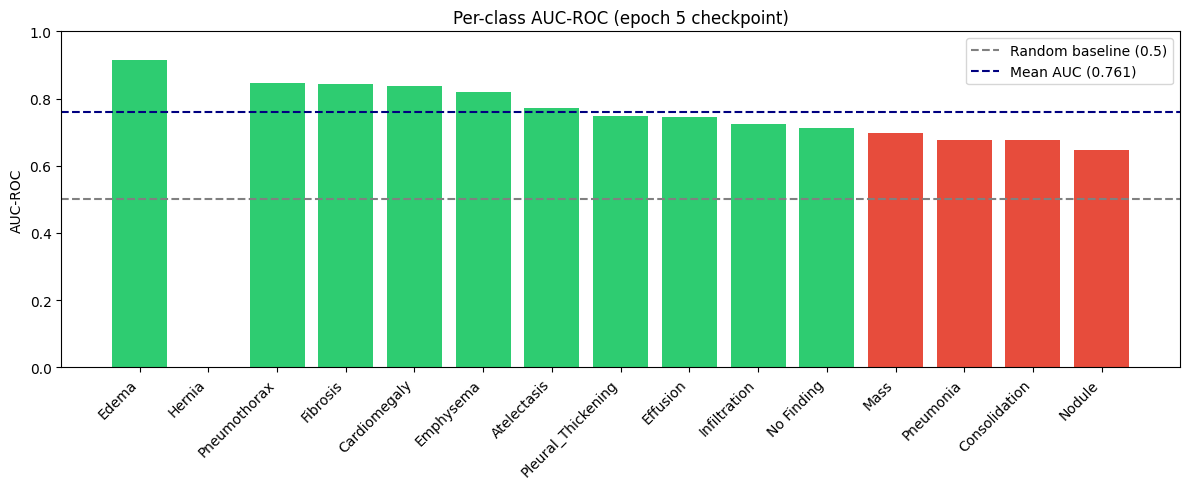

In [18]:
# bar chart of AUC-ROC per class
if all_probs is not None:
    sorted_aucs = dict(sorted(aucs.items(), key=lambda x: x[1], reverse=True))

    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['#e74c3c' if v < 0.7 else '#2ecc71' for v in sorted_aucs.values()]
    ax.bar(sorted_aucs.keys(), sorted_aucs.values(), color=colors)
    ax.axhline(0.5, color='gray', linestyle='--', label='Random baseline (0.5)')
    ax.axhline(mean_auc, color='navy', linestyle='--', label=f'Mean AUC ({mean_auc:.3f})')
    ax.set_ylim(0, 1)
    ax.set_ylabel('AUC-ROC')
    ax.set_title('Per-class AUC-ROC (epoch 5 checkpoint)')
    ax.set_xticklabels(sorted_aucs.keys(), rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 4b. Confusion Matrix & Classification Report

Per-class TP / FP / FN / TN at threshold 0.5, plus a full sklearn classification report.

Per-class confusion values (threshold = 0.5):

                     TP   FP  FN   TN
Disease                              
Atelectasis          64  240   7  189
Cardiomegaly         11   68   7  414
Consolidation        29  308   4  159
Edema                13  191   0  296
Effusion             89  232  11  168
Emphysema            16   83   9  392
Fibrosis              5   59   3  433
Hernia                0    0   0  500
Infiltration        111  277   6  106
Mass                 24  203   9  264
No Finding           87   35  98  280
Nodule               19  152  17  312
Pleural_Thickening   13  136   9  342
Pneumonia             3  125   4  368
Pneumothorax         47  138  11  304


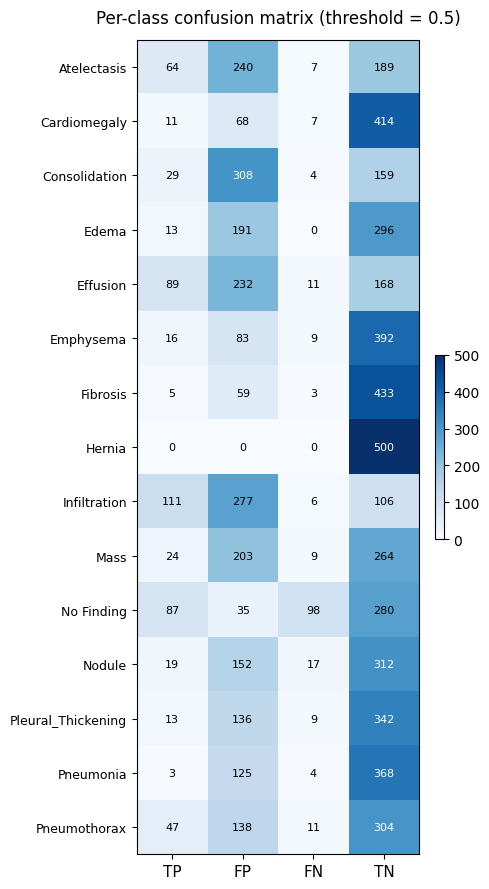

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix, classification_report

if all_probs is not None:
    THRESHOLD = 0.5
    preds_bin = (all_probs >= THRESHOLD).astype(int)   # (N, 15) binary

    # multilabel_confusion_matrix -> (15, 2, 2): [[TN, FP], [FN, TP]] per class
    mcm = multilabel_confusion_matrix(all_targets.astype(int), preds_bin)

    rows = []
    for i, label in enumerate(LABELS):
        tn, fp, fn, tp = mcm[i].ravel()
        rows.append({'Disease': label, 'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn)})
    cm_df = pd.DataFrame(rows).set_index('Disease')

    print(f'Per-class confusion values (threshold = {THRESHOLD}):\n')
    print(cm_df.to_string())

    # heatmap 
    fig, ax = plt.subplots(figsize=(5, 9))
    vals = cm_df.values.astype(float)
    im   = ax.imshow(vals, aspect='auto', cmap='Blues')
    ax.set_xticks(range(4))
    ax.set_xticklabels(['TP', 'FP', 'FN', 'TN'], fontsize=11)
    ax.set_yticks(range(len(LABELS)))
    ax.set_yticklabels(LABELS, fontsize=9)
    for i in range(len(LABELS)):
        for j in range(4):
            color = 'white' if vals[i, j] > vals.max() * 0.6 else 'black'
            ax.text(j, i, str(int(vals[i, j])), ha='center', va='center',
                    fontsize=8, color=color)
    plt.colorbar(im, ax=ax, fraction=0.03)
    ax.set_title(f'Per-class confusion matrix (threshold = {THRESHOLD})', pad=12)
    plt.tight_layout()
    plt.show()

In [20]:
# Classification report — precision / recall / F1 per class
if all_probs is not None:
    print(f'Classification Report (threshold = {THRESHOLD}):\n')
    print(classification_report(
        all_targets.astype(int), preds_bin,
        target_names=LABELS, zero_division=0
    ))

Classification Report (threshold = 0.5):

                    precision    recall  f1-score   support

       Atelectasis       0.21      0.90      0.34        71
      Cardiomegaly       0.14      0.61      0.23        18
     Consolidation       0.09      0.88      0.16        33
             Edema       0.06      1.00      0.12        13
          Effusion       0.28      0.89      0.42       100
         Emphysema       0.16      0.64      0.26        25
          Fibrosis       0.08      0.62      0.14         8
            Hernia       0.00      0.00      0.00         0
      Infiltration       0.29      0.95      0.44       117
              Mass       0.11      0.73      0.18        33
        No Finding       0.71      0.47      0.57       185
            Nodule       0.11      0.53      0.18        36
Pleural_Thickening       0.09      0.59      0.15        22
         Pneumonia       0.02      0.43      0.04         7
      Pneumothorax       0.25      0.81      0.39        

## 5. GradCAM Visualization

Shows which image regions drove the top prediction.  
Change `SAMPLE_IMAGE` to any chest X-ray PNG/JPG path.

In [21]:
def get_gradcam(model, image_t, age_t, gender_t, class_idx):
    """GradCAM heatmap for a given class. Returns (224,224) array in [0,1]."""
    activations, gradients = {}, {}

    def fwd(m, i, o):        activations['v'] = o.detach()
    def bwd(m, gi, go):      gradients['v']   = go[0].detach()

    layer = model.features.denseblock4
    h1 = layer.register_forward_hook(fwd)
    h2 = layer.register_full_backward_hook(bwd)

    out = model(
        image_t.unsqueeze(0).to(DEVICE),
        age_t.unsqueeze(0).to(DEVICE),
        gender_t.unsqueeze(0).to(DEVICE)
    )
    model.zero_grad()
    out[0, class_idx].backward()

    acts    = activations['v']
    grads   = gradients['v']
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam     = torch.relu((weights * acts).sum(dim=1).squeeze()).cpu().numpy()
    cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam     = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize((224, 224), Image.BILINEAR)) / 255.0

    h1.remove()
    h2.remove()
    return cam

In [ ]:
SAMPLE_IMAGE  = 'path/to/your/chest_xray.png'
SAMPLE_AGE    = 55    # raw age
SAMPLE_GENDER = 'M'   # 'M' or 'F'

if not os.path.exists(SAMPLE_IMAGE):
    print(f'Image not found: {SAMPLE_IMAGE}')
    print('Update SAMPLE_IMAGE above to a real chest X-ray path.')
else:
    transform = get_transforms(train=False)
    img_pil   = Image.open(SAMPLE_IMAGE).convert('RGB')
    img_t     = transform(img_pil)
    age_t     = torch.tensor([SAMPLE_AGE / 100.0], dtype=torch.float32)
    gender_t  = torch.tensor([0.0 if SAMPLE_GENDER == 'M' else 1.0], dtype=torch.float32)

    # get predictions
    with torch.no_grad():
        logits = model(
            img_t.unsqueeze(0).to(DEVICE),
            age_t.unsqueeze(0).to(DEVICE),
            gender_t.unsqueeze(0).to(DEVICE)
        )
    sample_probs = torch.sigmoid(logits).squeeze().cpu().numpy()
    top_class    = int(np.argmax(sample_probs))

    print(f'Top prediction: {LABELS[top_class]} ({sample_probs[top_class]:.1%})')
    print('All probabilities:')
    for i, (lbl, p) in enumerate(zip(LABELS, sample_probs)):
        marker = ' ÃƒÂ¢Ã¢â‚¬â€Ã¢â€šÂ¬' if i == top_class else ''
        print(f'  {lbl:<25} {p:.1%}{marker}')

    # GradCAM
    cam     = get_gradcam(model, img_t, age_t, gender_t, top_class)
    img_arr = np.array(img_pil.resize((224, 224))) / 255.0
    overlay = np.clip(0.6 * img_arr + 0.4 * cm.jet(cam)[:, :, :3], 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(img_arr, cmap='gray');  axes[0].set_title('Original');              axes[0].axis('off')
    axes[1].imshow(cam, cmap='jet');       axes[1].set_title(f'GradCAM: {LABELS[top_class]}'); axes[1].axis('off')
    axes[2].imshow(overlay);              axes[2].set_title('Overlay');                axes[2].axis('off')
    plt.suptitle(f'GradCAM visualization ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â top class: {LABELS[top_class]} ({sample_probs[top_class]:.1%})')
    plt.tight_layout()
    plt.show()

Image not found: path/to/your/chest_xray.png
Update SAMPLE_IMAGE above to a real chest X-ray path.
